In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import sklearn
import warnings
warnings.filterwarnings('ignore')

In [2]:
df= pd.read_csv('Downloads/Housing.csv')
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [3]:
df.shape

(545, 13)

In [4]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 69.2 KB


In [6]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [7]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

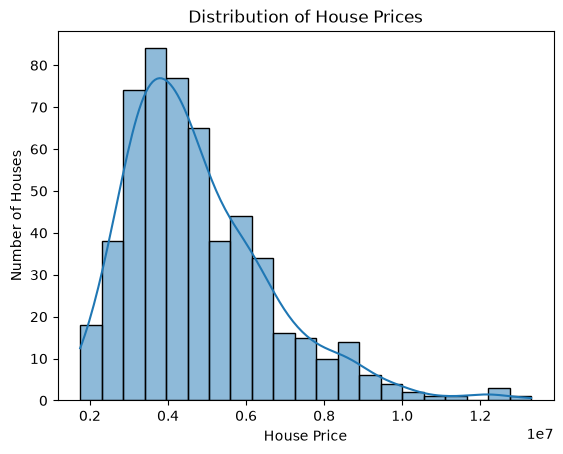

In [9]:
sns.histplot(df['price'], kde=True)
plt.xlabel('House Price')
plt.ylabel('Number of Houses')
plt.title('Distribution of House Prices')
plt.show()

In [10]:
df['price'].describe()

count    5.450000e+02
mean     4.766729e+06
std      1.870440e+06
min      1.750000e+06
25%      3.430000e+06
50%      4.340000e+06
75%      5.740000e+06
max      1.330000e+07
Name: price, dtype: float64

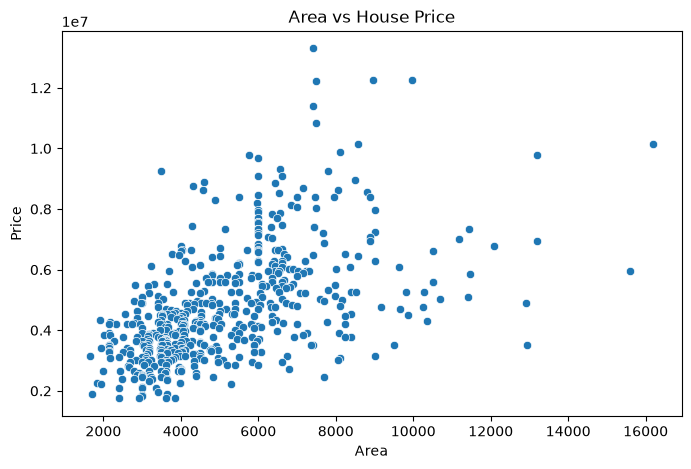

In [11]:
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x='area', y='price')

plt.xlabel('Area')
plt.ylabel('Price')
plt.title('Area vs House Price')

plt.show()

In [12]:
df['area'].corr(df['price'])

np.float64(0.5359973457780803)

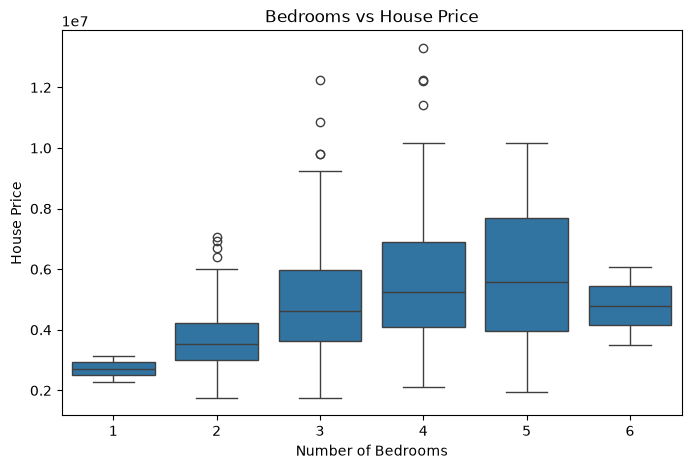

In [13]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x='bedrooms', y='price')

plt.xlabel('Number of Bedrooms')
plt.ylabel('House Price')
plt.title('Bedrooms vs House Price')

plt.show()

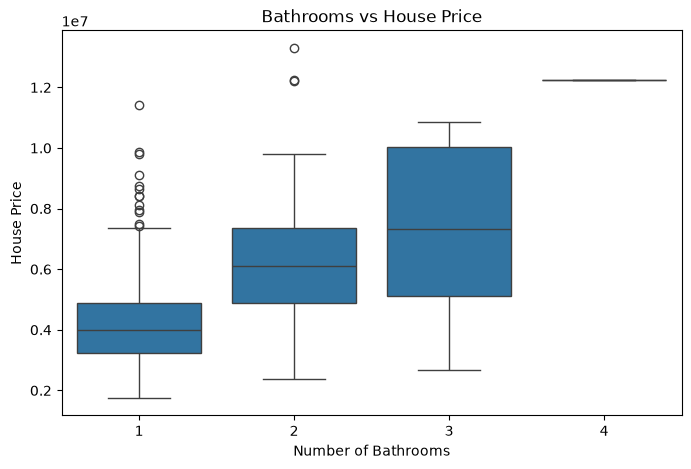

In [14]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x='bathrooms', y='price')

plt.xlabel('Number of Bathrooms')
plt.ylabel('House Price')
plt.title('Bathrooms vs House Price')

plt.show()

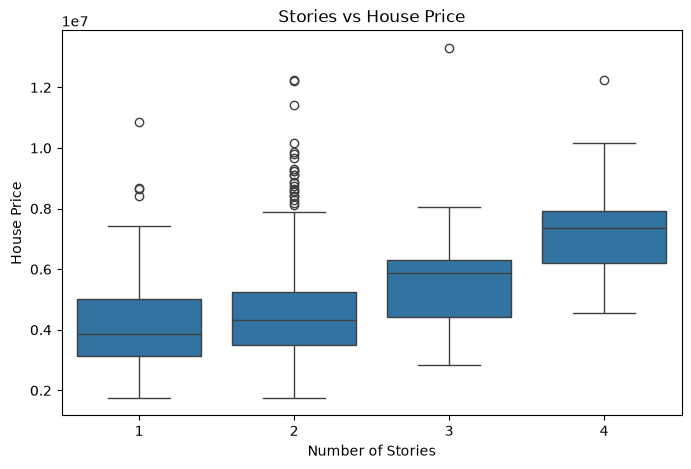

In [15]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x='stories', y='price')

plt.xlabel('Number of Stories')
plt.ylabel('House Price')
plt.title('Stories vs House Price')

plt.show()

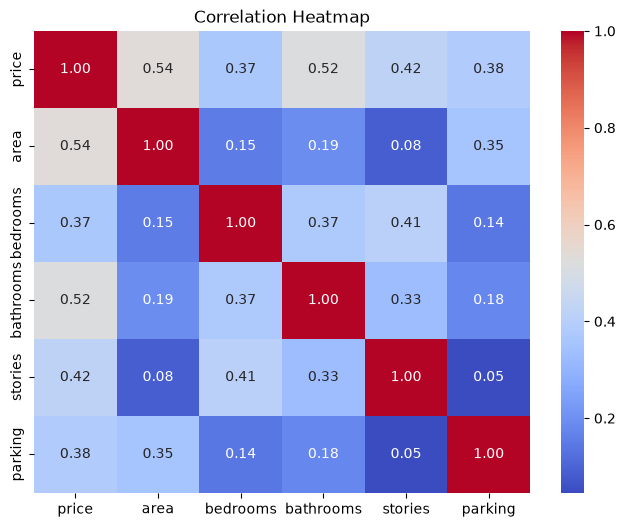

In [16]:
plt.figure(figsize=(8, 6))

correlation = df.select_dtypes(include='number').corr()

sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Heatmap')

plt.show()

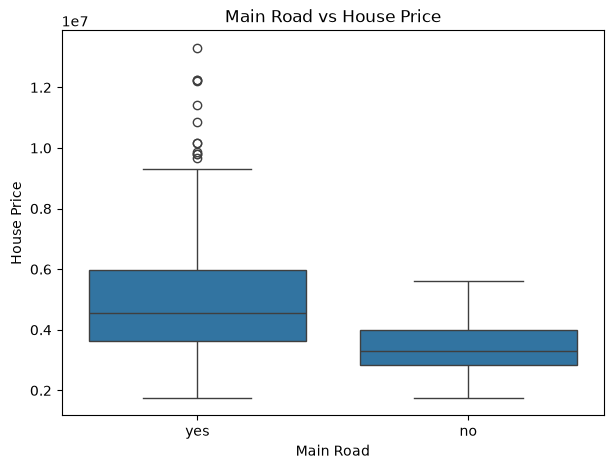

In [17]:
plt.figure(figsize=(7, 5))

sns.boxplot(data=df, x='mainroad', y='price')

plt.xlabel('Main Road')
plt.ylabel('House Price')
plt.title('Main Road vs House Price')

plt.show()

In [18]:
df['mainroad'].value_counts()

mainroad
yes    468
no      77
Name: count, dtype: int64

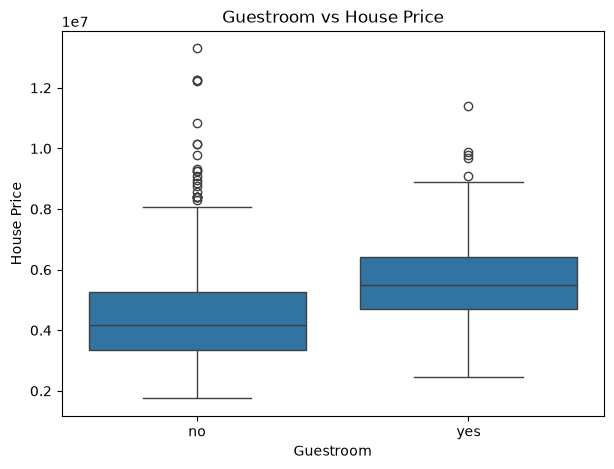

In [19]:
plt.figure(figsize=(7, 5))

sns.boxplot(data=df, x='guestroom', y='price')

plt.xlabel('Guestroom')
plt.ylabel('House Price')
plt.title('Guestroom vs House Price')

plt.show()

In [20]:
df['guestroom'].value_counts()

guestroom
no     448
yes     97
Name: count, dtype: int64

In [21]:
df['basement'].value_counts()

basement
no     354
yes    191
Name: count, dtype: int64

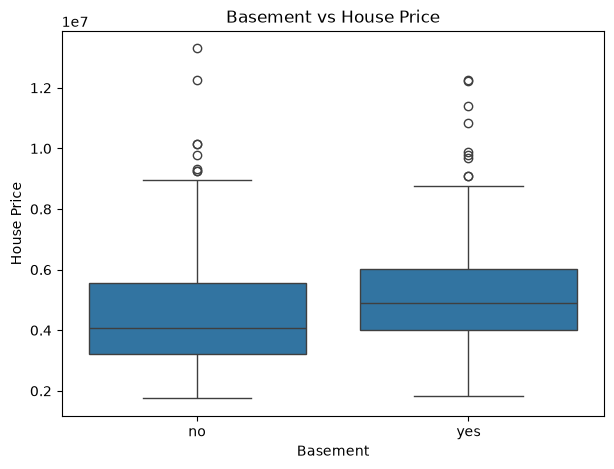

In [22]:
plt.figure(figsize=(7, 5))

sns.boxplot(data=df, x='basement', y='price')

plt.xlabel('Basement')
plt.ylabel('House Price')
plt.title('Basement vs House Price')

plt.show()

In [23]:
df['hotwaterheating'].value_counts()

hotwaterheating
no     520
yes     25
Name: count, dtype: int64

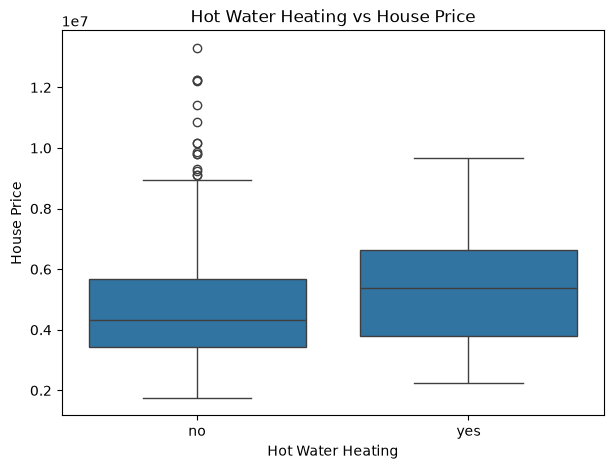

In [24]:
plt.figure(figsize=(7, 5))

sns.boxplot(data=df, x='hotwaterheating', y='price')

plt.xlabel('Hot Water Heating')
plt.ylabel('House Price')
plt.title('Hot Water Heating vs House Price')

plt.show()

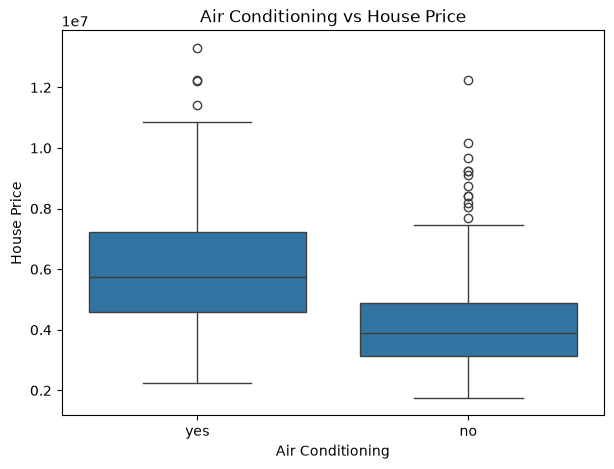

In [25]:
plt.figure(figsize=(7, 5))

sns.boxplot(data=df, x='airconditioning', y='price')

plt.xlabel('Air Conditioning')
plt.ylabel('House Price')
plt.title('Air Conditioning vs House Price')

plt.show()

In [26]:
df['airconditioning'].value_counts()

airconditioning
no     373
yes    172
Name: count, dtype: int64

In [27]:
df['prefarea'].value_counts()

prefarea
no     417
yes    128
Name: count, dtype: int64

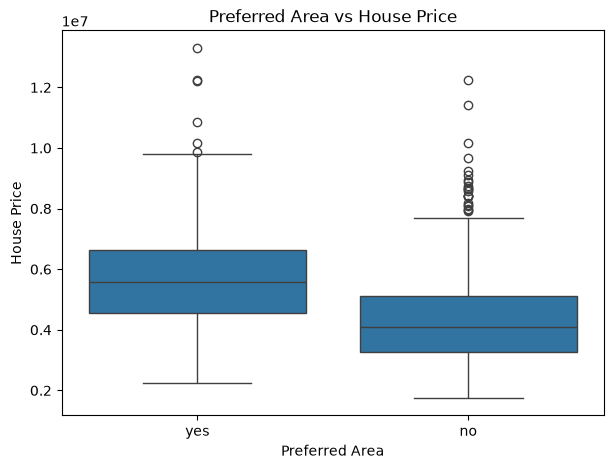

In [28]:
plt.figure(figsize=(7, 5))

sns.boxplot(data=df, x='prefarea', y='price')

plt.xlabel('Preferred Area')
plt.ylabel('House Price')
plt.title('Preferred Area vs House Price')

plt.show()

In [29]:
df['furnishingstatus'].value_counts()

furnishingstatus
semi-furnished    227
unfurnished       178
furnished         140
Name: count, dtype: int64

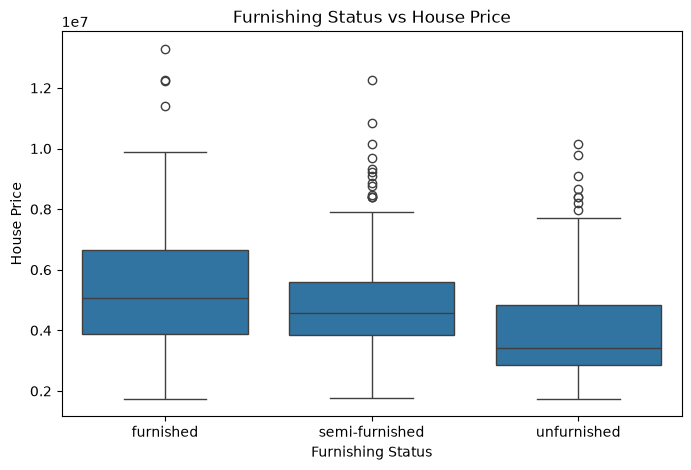

In [30]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x='furnishingstatus', y='price')

plt.xlabel('Furnishing Status')
plt.ylabel('House Price')
plt.title('Furnishing Status vs House Price')

plt.show()

In [31]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df['price'] < lower_bound) |
    (df['price'] > upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of outliers:", len(outliers))

Q1: 3430000.0
Q3: 5740000.0
IQR: 2310000.0
Lower Bound: -35000.0
Upper Bound: 9205000.0
Number of outliers: 15


In [32]:
outliers[['price', 'area', 'bedrooms', 'bathrooms', 'stories',
          'parking', 'mainroad', 'prefarea', 'furnishingstatus']]

,price,area,bedrooms,bathrooms,stories,parking,mainroad,prefarea,furnishingstatus
0,13300000,7420,4,2,3,2,yes,yes,furnished
1,12250000,8960,4,4,4,3,yes,no,furnished
2,12250000,9960,3,2,2,2,yes,yes,semi-furnished
3,12215000,7500,4,2,2,3,yes,yes,furnished
4,11410000,7420,4,1,2,2,yes,no,furnished
5,10850000,7500,3,3,1,2,yes,yes,semi-furnished
6,10150000,8580,4,3,4,2,yes,yes,semi-furnished
7,10150000,16200,5,3,2,0,yes,no,unfurnished
8,9870000,8100,4,1,2,2,yes,yes,furnished
9,9800000,5750,3,2,4,1,yes,yes,unfurnished


In [33]:
outliers

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [34]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [35]:
df['furnishingstatus'].value_counts()

furnishingstatus
semi-furnished    227
unfurnished       178
furnished         140
Name: count, dtype: int64

In [36]:
df1=df.copy()

In [37]:
df1

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [38]:
df1.duplicated().sum()

np.int64(0)

In [39]:
df1['mainroad'] = df['mainroad'].map({"no" : 0,"yes" : 1})
df1['guestroom'] = df['guestroom'].map({"no" : 0,"yes" : 1})
df1['basement'] = df['basement'].map({"no" : 0,"yes" : 1})
df1['hotwaterheating'] = df['hotwaterheating'].map({"no" : 0,"yes" : 1})
df1['airconditioning'] = df['airconditioning'].map({"no" : 0,"yes" : 1})
df1['prefarea'] = df['prefarea'].map({"no" : 0,"yes" : 1})



In [40]:
df1

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,furnished
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,furnished
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,furnished
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,1,0,1,0,0,2,0,unfurnished
541,1767150,2400,3,1,1,0,0,0,0,0,0,0,semi-furnished
542,1750000,3620,2,1,1,1,0,0,0,0,0,0,unfurnished
543,1750000,2910,3,1,1,0,0,0,0,0,0,0,furnished


In [41]:
df1 = pd.get_dummies(df1,columns = ['furnishingstatus'],drop_first=True)

In [42]:
df1

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,1,0,1,0,0,2,0,False,True
541,1767150,2400,3,1,1,0,0,0,0,0,0,0,True,False
542,1750000,3620,2,1,1,1,0,0,0,0,0,0,False,True
543,1750000,2910,3,1,1,0,0,0,0,0,0,0,False,False


In [43]:
df1=df1.astype(int)

In [44]:
df1

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,1,0,1,0,0,2,0,0,1
541,1767150,2400,3,1,1,0,0,0,0,0,0,0,1,0
542,1750000,3620,2,1,1,1,0,0,0,0,0,0,0,1
543,1750000,2910,3,1,1,0,0,0,0,0,0,0,0,0


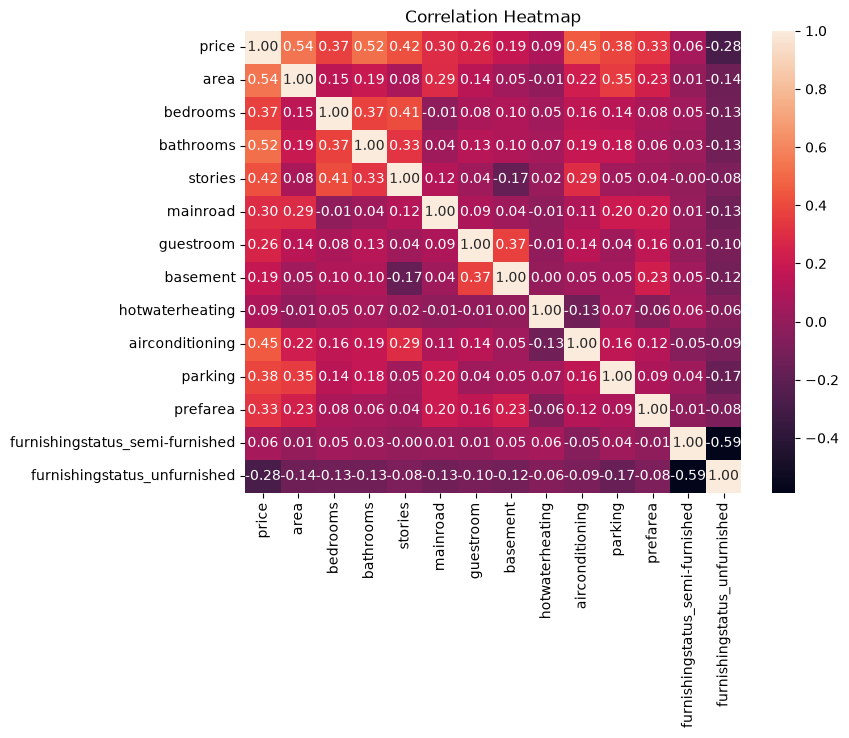

In [45]:
plt.figure(figsize=(8, 6))

correlation = df1.select_dtypes(include='number').corr()

sns.heatmap(correlation, annot=True, fmt='.2f')

plt.title('Correlation Heatmap')

plt.show()

In [46]:
df1.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus_semi-furnished',
       'furnishingstatus_unfurnished'],
      dtype='str')

In [47]:
df1

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,1,0,1,0,0,2,0,0,1
541,1767150,2400,3,1,1,0,0,0,0,0,0,0,1,0
542,1750000,3620,2,1,1,1,0,0,0,0,0,0,0,1
543,1750000,2910,3,1,1,0,0,0,0,0,0,0,0,0


In [48]:
from sklearn.preprocessing import StandardScaler
cols = [ 'area', 'bedrooms', 'bathrooms', 'stories','parking']
scaler = StandardScaler()

df1[cols] = scaler.fit_transform(df1[cols])

In [49]:
df1

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,1.046726,1.403419,1.421812,1.378217,1,0,0,0,1,1.517692,1,0,0
1,12250000,1.757010,1.403419,5.405809,2.532024,1,0,0,0,1,2.679409,0,0,0
2,12250000,2.218232,0.047278,1.421812,0.224410,1,0,1,0,0,1.517692,1,1,0
3,12215000,1.083624,1.403419,1.421812,0.224410,1,0,1,0,1,2.679409,1,0,0
4,11410000,1.046726,1.403419,-0.570187,0.224410,1,1,1,0,1,1.517692,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,-0.991879,-1.308863,-0.570187,-0.929397,1,0,1,0,0,1.517692,0,0,1
541,1767150,-1.268613,0.047278,-0.570187,-0.929397,0,0,0,0,0,-0.805741,0,1,0
542,1750000,-0.705921,-1.308863,-0.570187,-0.929397,1,0,0,0,0,-0.805741,0,0,1
543,1750000,-1.033389,0.047278,-0.570187,-0.929397,0,0,0,0,0,-0.805741,0,0,0


In [50]:
from scipy.stats import pearsonr

# ----------------------------------
# Pearson Correlation Calculation
# ----------------------------------

# List of features to check against target
selected_features = ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus_semi-furnished',
       'furnishingstatus_unfurnished']

correlations = {
    feature: pearsonr(df1[feature], df1['price'])[0]
    for feature in selected_features
}
correlation_df = pd.DataFrame(list(correlations.items()), columns=['Feature', 'Pearson Correlation'])
correlation_df.sort_values(by='Pearson Correlation', ascending=False)

,Feature,Pearson Correlation
0,area,0.535997
2,bathrooms,0.517545
8,airconditioning,0.452954
3,stories,0.420712
9,parking,0.384394
1,bedrooms,0.366494
10,prefarea,0.329777
4,mainroad,0.296898
5,guestroom,0.255517
6,basement,0.187057


In [51]:
df1.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,1.046726,1.403419,1.421812,1.378217,1,0,0,0,1,1.517692,1,0,0
1,12250000,1.757010,1.403419,5.405809,2.532024,1,0,0,0,1,2.679409,0,0,0
2,12250000,2.218232,0.047278,1.421812,0.224410,1,0,1,0,0,1.517692,1,1,0
3,12215000,1.083624,1.403419,1.421812,0.224410,1,0,1,0,1,2.679409,1,0,0
4,11410000,1.046726,1.403419,-0.570187,0.224410,1,1,1,0,1,1.517692,0,0,0


In [52]:
cat_features = [
    'mainroad', 'guestroom',
    'basement', 'hotwaterheating', 'airconditioning',
    'prefarea', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished'
]

In [53]:

df1['price_bin'] = pd.qcut(df1['price'], q=4, labels=False)
df1

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished,price_bin
0,13300000,1.046726,1.403419,1.421812,1.378217,1,0,0,0,1,1.517692,1,0,0,3
1,12250000,1.757010,1.403419,5.405809,2.532024,1,0,0,0,1,2.679409,0,0,0,3
2,12250000,2.218232,0.047278,1.421812,0.224410,1,0,1,0,0,1.517692,1,1,0,3
3,12215000,1.083624,1.403419,1.421812,0.224410,1,0,1,0,1,2.679409,1,0,0,3
4,11410000,1.046726,1.403419,-0.570187,0.224410,1,1,1,0,1,1.517692,0,0,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,-0.991879,-1.308863,-0.570187,-0.929397,1,0,1,0,0,1.517692,0,0,1,0
541,1767150,-1.268613,0.047278,-0.570187,-0.929397,0,0,0,0,0,-0.805741,0,1,0,0
542,1750000,-0.705921,-1.308863,-0.570187,-0.929397,1,0,0,0,0,-0.805741,0,0,1,0
543,1750000,-1.033389,0.047278,-0.570187,-0.929397,0,0,0,0,0,-0.805741,0,0,0,0


In [54]:
from scipy.stats import chi2_contingency
import pandas as pd

alpha = 0.05
chi2_results = {}

for col in cat_features:
    contingency = pd.crosstab(df1[col], df1['price_bin'])
    chi2_stat, p_val, _, _ = chi2_contingency(contingency)
    decision = 'Reject Null (Keep Feature)' if p_val < alpha else 'Accept Null (Drop Feature)'
    chi2_results[col] = {
        'chi2_statistic': chi2_stat,
        'p_value': p_val,
        'Decision': decision
    }

chi2_df = pd.DataFrame(chi2_results).T
chi2_df = chi2_df.sort_values(by='p_value')
chi2_df

,chi2_statistic,p_value,Decision
airconditioning,109.251342,0.0,Reject Null (Keep Feature)
furnishingstatus_unfurnished,93.40622,0.0,Reject Null (Keep Feature)
mainroad,66.19413,0.0,Reject Null (Keep Feature)
prefarea,64.725448,0.0,Reject Null (Keep Feature)
guestroom,51.705899,0.0,Reject Null (Keep Feature)
furnishingstatus_semi-furnished,50.574414,0.0,Reject Null (Keep Feature)
basement,31.525879,0.000001,Reject Null (Keep Feature)
hotwaterheating,7.757896,0.051289,Accept Null (Drop Feature)


In [55]:
df1

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished,price_bin
0,13300000,1.046726,1.403419,1.421812,1.378217,1,0,0,0,1,1.517692,1,0,0,3
1,12250000,1.757010,1.403419,5.405809,2.532024,1,0,0,0,1,2.679409,0,0,0,3
2,12250000,2.218232,0.047278,1.421812,0.224410,1,0,1,0,0,1.517692,1,1,0,3
3,12215000,1.083624,1.403419,1.421812,0.224410,1,0,1,0,1,2.679409,1,0,0,3
4,11410000,1.046726,1.403419,-0.570187,0.224410,1,1,1,0,1,1.517692,0,0,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,-0.991879,-1.308863,-0.570187,-0.929397,1,0,1,0,0,1.517692,0,0,1,0
541,1767150,-1.268613,0.047278,-0.570187,-0.929397,0,0,0,0,0,-0.805741,0,1,0,0
542,1750000,-0.705921,-1.308863,-0.570187,-0.929397,1,0,0,0,0,-0.805741,0,0,1,0
543,1750000,-1.033389,0.047278,-0.570187,-0.929397,0,0,0,0,0,-0.805741,0,0,0,0


In [56]:
df1.dtypes

price                                int64
area                               float64
bedrooms                           float64
bathrooms                          float64
stories                            float64
mainroad                             int64
guestroom                            int64
basement                             int64
hotwaterheating                      int64
airconditioning                      int64
parking                            float64
prefarea                             int64
furnishingstatus_semi-furnished      int64
furnishingstatus_unfurnished         int64
price_bin                            int64
dtype: object

In [117]:
X = df1.drop(['price','hotwaterheating','price_bin'], axis=1)
y = df1['price']

In [118]:
X

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,1.046726,1.403419,1.421812,1.378217,1,0,0,1,1.517692,1,0,0
1,1.757010,1.403419,5.405809,2.532024,1,0,0,1,2.679409,0,0,0
2,2.218232,0.047278,1.421812,0.224410,1,0,1,0,1.517692,1,1,0
3,1.083624,1.403419,1.421812,0.224410,1,0,1,1,2.679409,1,0,0
4,1.046726,1.403419,-0.570187,0.224410,1,1,1,1,1.517692,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
540,-0.991879,-1.308863,-0.570187,-0.929397,1,0,1,0,1.517692,0,0,1
541,-1.268613,0.047278,-0.570187,-0.929397,0,0,0,0,-0.805741,0,1,0
542,-0.705921,-1.308863,-0.570187,-0.929397,1,0,0,0,-0.805741,0,0,1
543,-1.033389,0.047278,-0.570187,-0.929397,0,0,0,0,-0.805741,0,0,0


In [119]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [120]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (436, 12)
X_test: (109, 12)
y_train: (436,)
y_test: (109,)


In [121]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](12,)","[ 512686.97, 57352.5 , 555597.96,..., 612286.68,-128540.15,-427526.65]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](12,)","['area','bedrooms','bathrooms',...,'prefarea', 'furnishingstatus_semi-furnished','furnishingstatus_unfurnished']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.071e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,12
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(12)


In [122]:
y_pred = model.predict(X_test)

In [123]:
print(y_pred[:10])

[5248073.6301381  7220404.99546845 3141248.66246577 4599017.19821428
 3328649.85220602 3553760.97405167 5619356.95345774 6415069.22530295
 2760818.06915403 2674104.75592535]


In [124]:
comparison = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred
})

comparison.head(10)

,Actual Price,Predicted Price
0,4060000,5.248074e+06
1,6650000,7.220405e+06
2,3710000,3.141249e+06
3,6440000,4.599017e+06
4,2800000,3.328650e+06
5,4900000,3.553761e+06
6,5250000,5.619357e+06
7,4543000,6.415069e+06
8,2450000,2.760818e+06
9,3353000,2.674105e+06


In [125]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 994646.78664866
MSE: 1816506314271.8042
RMSE: 1347778.2882476645
R² Score: 0.6406210170726108


In [126]:
accuracy = 100 - (mae / y_test.mean() * 100)

print("Approximate Accuracy:", accuracy, "%")

Approximate Accuracy: 80.13700454366419 %


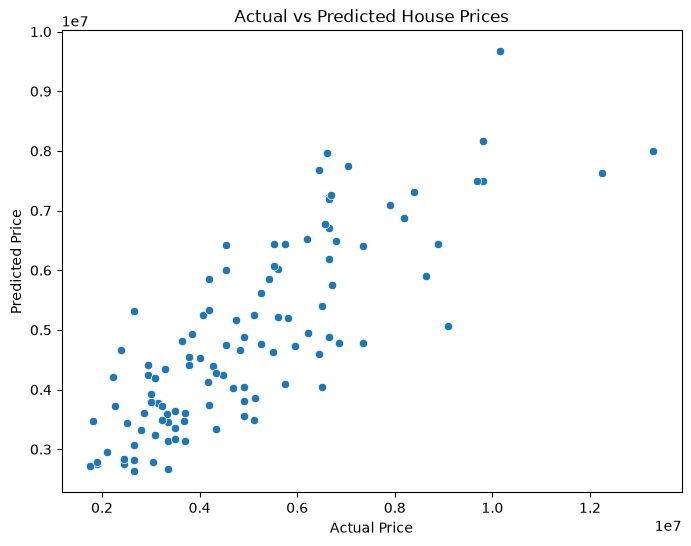

In [127]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

sns.scatterplot(x=y_test, y=y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

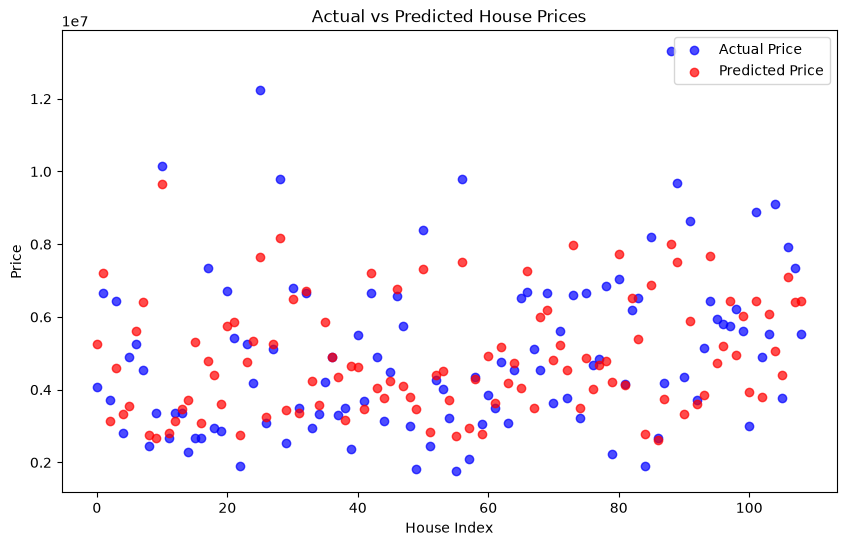

In [128]:
plt.figure(figsize=(10, 6))

plt.scatter(range(len(y_test)), y_test, 
            label='Actual Price', color='blue', alpha=0.7)

plt.scatter(range(len(y_pred)), y_pred, 
            label='Predicted Price', color='red', alpha=0.7)

plt.xlabel("House Index")
plt.ylabel("Price")
plt.title("Actual vs Predicted House Prices")
plt.legend()

plt.show()

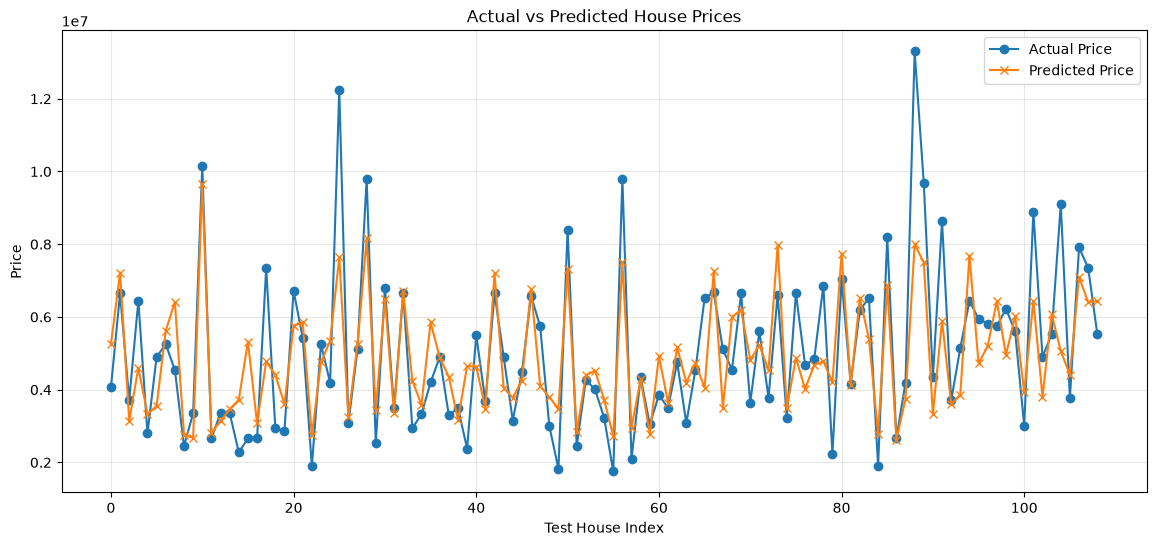

In [129]:
plt.figure(figsize=(14, 6))

plt.plot(y_test.values, label='Actual Price', marker='o')
plt.plot(y_pred, label='Predicted Price', marker='x')

plt.xlabel('Test House Index')
plt.ylabel('Price')
plt.title('Actual vs Predicted House Prices')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [130]:
import pickle

with open('house_price_model.pkl', 'wb') as file:
    pickle.dump(model, file)

In [131]:
print(scaler)

StandardScaler()


In [142]:
import pickle

with open('scaler.pkl', 'wb') as file:
    pickle.dump(scaler, file)

In [143]:
comparison = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred
})

comparison['Absolute Error'] = abs(
    comparison['Actual Price'] - comparison['Predicted Price']
)

comparison['Error %'] = (
    comparison['Absolute Error'] /
    comparison['Actual Price']
) * 100
comparison=comparison.astype(int)
comparison.head(10)

,Actual Price,Predicted Price,Absolute Error,Error %
0,4060000,5248073,1188073,29
1,6650000,7220404,570404,8
2,3710000,3141248,568751,15
3,6440000,4599017,1840982,28
4,2800000,3328649,528649,18
5,4900000,3553760,1346239,27
6,5250000,5619356,369356,7
7,4543000,6415069,1872069,41
8,2450000,2760818,310818,12
9,3353000,2674104,678895,20


In [144]:
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished
